Classification: inference
=========================

In this notebook we demonstrate how to use the script `scripts/classification/main_classification_inference.py` to identify organisms in clips to taxonomic groups. 

We first import the necessary packages, and specifically import `main_classification_inference`: 

In [8]:
import os, sys 
from pathlib import Path
import yaml

from mzbsuite.utils import cfg_to_arguments

from scripts.classification.main_classification_inference import main as classification
?classification

Signature: classification(args, cfg)
Docstring:
Function to run inference on macrozoobenthos images clips, using a trained model.

Parameters
----------
args : argparse.Namespace
    Namespace containing the arguments passed to the script. Notably:

        - input_dir: path to the directory containing the images to be classified
        - taxonomy_file: path to the csv file containing the taxonomy of the classes
        - input_model: path to the directory containing the model to be used for inference
        - output_dir: path to the directory where the results will be saved
        - config_file: path to the config file with train / inference parameters

cfg : dict
    Dictionary containing the configuration parameters.

Returns
-------
None. Saves the results in the specified folder.
File:      d:\mzb-suite\scripts\classification\main_classification_inference.py
Type:      function

Next we declare the running parameters,  telling the script where to find the input data, the model and where to put the outputs. In this notebook, we pass these as a Python dictionary, but a shell (`.sh`) and Windows batch (`.bat`) files achieving the same result can be found in `workflows`. 

In [9]:
cwd = Path.cwd()
ROOT_DIR = cwd.parent.absolute()

# Alternatively, change to your working directory:
# ROOT_DIR = Path("path/to/your/working/dir/here")

MODEL = "efficientnet-b2-v0"

arguments = {
    "input_dir": ROOT_DIR / "data/mzb_example_data/training_dataset/val_set",
    "input_model": ROOT_DIR / f"models/mzb-classification-models/{MODEL}", 
    "output_dir": ROOT_DIR / "results/mzb_example_data/classification",
    "config_file": ROOT_DIR / "configs/mzb_example_config.yaml",
    "taxonomy_file": ROOT_DIR / "data/mzb_example_data/MZB_taxonomy.csv"
}
    
with open(str(arguments["config_file"]), "r") as f:
    cfg = yaml.load(f, Loader=yaml.FullLoader)

cfg["trcl_gpu_ids"] = None
cfg

{'glob_random_seed': 222,
 'glob_root_folder': '/home/mzbuser/work/mzb-suite',
 'glob_blobs_folder': '/home/mzbuser/work/mzb-suite/data/derived/blobs/',
 'glob_local_format': 'pdf',
 'model_logger': 'wandb',
 'impa_image_format': 'jpg',
 'impa_clip_areas': [2700, 4700, -1, -1],
 'impa_area_threshold': 5000,
 'impa_gaussian_blur': [21, 21],
 'impa_gaussian_blur_passes': 3,
 'impa_adaptive_threshold_block_size': 351,
 'impa_mask_postprocess_kernel': [11, 11],
 'impa_mask_postprocess_passes': 5,
 'impa_bounding_box_buffer': 200,
 'impa_save_clips_plus_features': True,
 'lset_class_cut': 'order',
 'lset_val_size': 0.1,
 'trcl_learning_rate': 0.0001,
 'trcl_batch_size': 8,
 'trcl_weight_decay': 0,
 'trcl_step_size_decay': 5,
 'trcl_number_epochs': 75,
 'trcl_save_topk': 1,
 'trcl_num_classes': 8,
 'trcl_model_pretrarch': 'convnext-small',
 'trcl_num_workers': 16,
 'trcl_wandb_project_name': 'mzb-classifiers',
 'trcl_logger': 'wandb',
 'trsk_learning_rate': 0.001,
 'trsk_batch_size': 32,
 't

We now need to transform parameters in the configuration file in a format that Python can understand (a dictionary in this case), we can use the provided helper function `cfg_to_arguments`: 

In [10]:
# Transforms configurations dicts to argparse arguments
args_p = cfg_to_arguments(arguments)
cfg_p = cfg_to_arguments(cfg)
print(str(cfg_p))

{'glob_random_seed': 222, 'glob_root_folder': '/home/mzbuser/work/mzb-suite', 'glob_blobs_folder': '/home/mzbuser/work/mzb-suite/data/derived/blobs/', 'glob_local_format': 'pdf', 'model_logger': 'wandb', 'impa_image_format': 'jpg', 'impa_clip_areas': [2700, 4700, -1, -1], 'impa_area_threshold': 5000, 'impa_gaussian_blur': [21, 21], 'impa_gaussian_blur_passes': 3, 'impa_adaptive_threshold_block_size': 351, 'impa_mask_postprocess_kernel': [11, 11], 'impa_mask_postprocess_passes': 5, 'impa_bounding_box_buffer': 200, 'impa_save_clips_plus_features': True, 'lset_class_cut': 'order', 'lset_val_size': 0.1, 'trcl_learning_rate': 0.0001, 'trcl_batch_size': 8, 'trcl_weight_decay': 0, 'trcl_step_size_decay': 5, 'trcl_number_epochs': 75, 'trcl_save_topk': 1, 'trcl_num_classes': 8, 'trcl_model_pretrarch': 'convnext-small', 'trcl_num_workers': 16, 'trcl_wandb_project_name': 'mzb-classifiers', 'trcl_logger': 'wandb', 'trsk_learning_rate': 0.001, 'trsk_batch_size': 32, 'trsk_weight_decay': 0, 'trsk_st

Once we have all set up, we can simply call the `inference_classifier` function, which will use the provided parameters to produce predictions. If `input_dir` is a validation set (i.e. called `val_set` and is structured hierarchically with classes' names), then a classification accuracy report and confusion matrix are also produced. 

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation set size: 52


c:\Users\Pegoraro\AppData\Local\miniforge3\envs\mzbsuite\lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
c:\Users\Pegoraro\AppData\Local\miniforge3\envs\mzbsuite\lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:429: Consider setting `persistent_workers=True` in 'predict_dataloader' to speed up the dataloader worker initialization.


Predicting DataLoader 0: 100%|██████████| 7/7 [00:00<00:00,  8.51it/s]


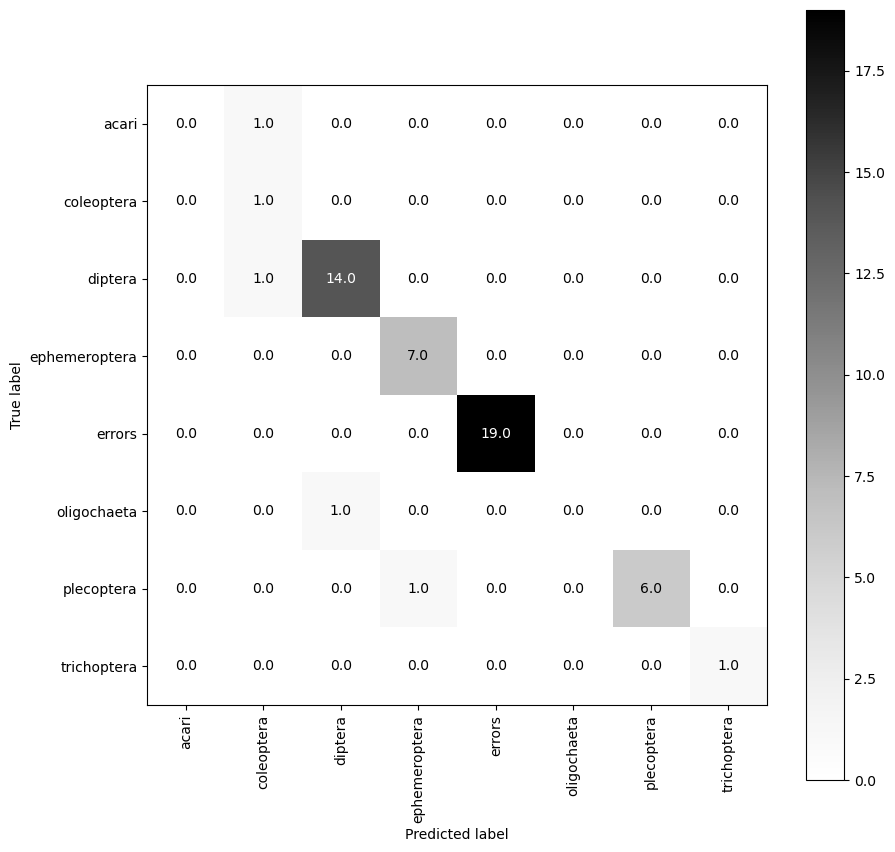

In [11]:
classification(args_p, cfg_p)

The produced confusion matrix show how many predictions the model made that corresponded to the real identity of the organism (on the diagonal), and also when the model was wrong what it guessed instead (off diagonal). 